In [2]:
# %% [markdown]
# # AI vs Real Image Classification with PyTorch (Local Jupyter Notebook)
# 
# This notebook uses **PyTorch** and **torchvision** to build a deep learning classifier that distinguishes AI‑generated images from real photographs.  
# Dataset: local folder `G:\AI Engineering\Python Programming for AI\Kaggle Competitions\AI vs Real Image`

# %% [code]
# ---------------------------
# 1. Install / Import Libraries
# ---------------------------
# If any package is missing, uncomment:
# !pip install torch torchvision matplotlib scikit-learn pandas pillow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% [markdown]

Using device: cpu


In [3]:
# ## 2. Explore Dataset Structure
# %% [code]
# Paths for Windows (use raw string)
BASE_PATH = Path(r"G:\AI Engineering\Python Programming for AI\Kaggle Competitions\AI vs Real Image")
AI_PATH = BASE_PATH / "Ai_generated_dataset"
REAL_PATH = BASE_PATH / "real_dataset"

# Check if paths exist
assert AI_PATH.exists(), f"AI path not found: {AI_PATH}"
assert REAL_PATH.exists(), f"Real path not found: {REAL_PATH}"

# List categories (animals, nature, city, food, people)
categories = [p.name for p in AI_PATH.iterdir() if p.is_dir()]
print("Categories:", categories)

# Count images per category
ai_counts = {cat: len(list((AI_PATH/cat).glob("*.png"))) for cat in categories}
real_counts = {cat: len(list((REAL_PATH/cat).glob("*.jpg"))) for cat in categories}
print("\nAI image counts:", ai_counts)
print("Real image counts:", real_counts)

# %% [markdown]

Categories: ['animals', 'city', 'food', 'nature', 'people']

AI image counts: {'animals': 50, 'city': 50, 'food': 50, 'nature': 50, 'people': 50}
Real image counts: {'animals': 148, 'city': 150, 'food': 150, 'nature': 150, 'people': 147}


In [4]:
# ## 3. Build DataFrame with Paths and Labels

# %% [code]
data = []
for cat in categories:
    # AI images (label = 1)
    for img_path in (AI_PATH/cat).glob("*.png"):
        data.append([str(img_path), cat, 1])
    # Real images (label = 0)
    for img_path in (REAL_PATH/cat).glob("*.jpg"):
        data.append([str(img_path), cat, 0])

df = pd.DataFrame(data, columns=["path", "category", "label"])
df["label_name"] = df["label"].map({1: "AI", 0: "Real"})
print(f"Total images: {len(df)}")
df.head()

# %% [markdown]

Total images: 995


,path,category,label,label_name
0,G:\AI Engineering\Python Programming for AI\Ka...,animals,1,AI
1,G:\AI Engineering\Python Programming for AI\Ka...,animals,1,AI
2,G:\AI Engineering\Python Programming for AI\Ka...,animals,1,AI
3,G:\AI Engineering\Python Programming for AI\Ka...,animals,1,AI
4,G:\AI Engineering\Python Programming for AI\Ka...,animals,1,AI


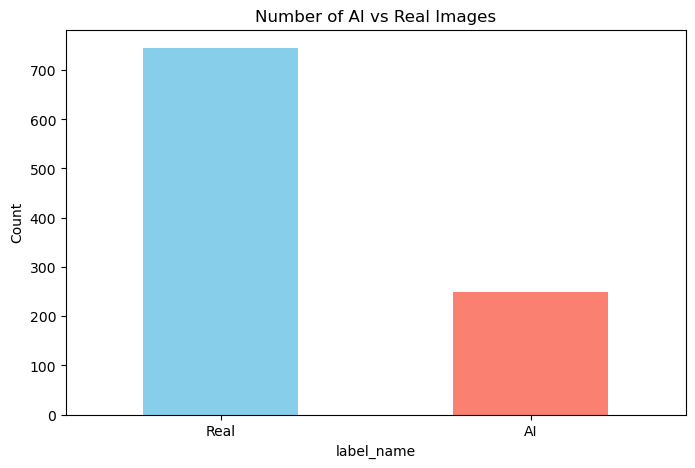

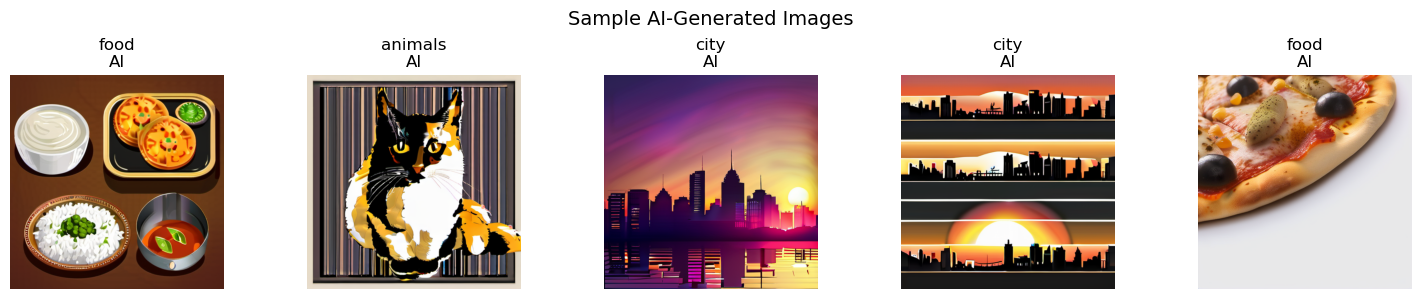

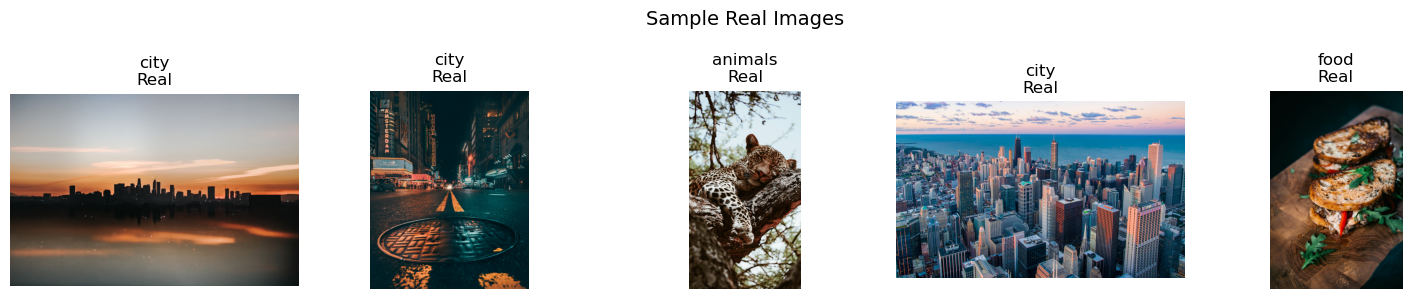

In [5]:

# ## 4. Visualize Class Balance and Sample Images

# %% [code]
plt.figure(figsize=(8,5))
df["label_name"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Number of AI vs Real Images")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

def show_sample_images(df, label_val, title, n=5):
    samples = df[df["label"]==label_val].sample(n, random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(15,3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["path"])
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{row['category']}\n{row['label_name']}")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(df, 1, "Sample AI‑Generated Images")
show_sample_images(df, 0, "Sample Real Images")

# %% [markdown]

In [6]:
# ## 5. Create PyTorch Dataset and DataLoaders

# %% [code]
# Define image transforms
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["path"]
        label = self.dataframe.iloc[idx]["label"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Split into train (80%) and validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

train_dataset = ImageDataset(train_df, transform=train_transforms)
val_dataset = ImageDataset(val_df, transform=val_transforms)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# %% [markdown]

Training samples: 796
Validation samples: 199


In [7]:


# ## 6. Define Model (ResNet34)

# %% [code]
def create_model(num_classes=2, model_name="resnet34"):
    if model_name == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    else:
        raise ValueError("Model not supported")
    
    # Replace the final fully connected layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model34 = create_model(num_classes=2, model_name="resnet34").to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model34.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(model34)

# %% [markdown]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# ## 7. Training Function

# %% [code]
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=5):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_acc = correct / total
        val_accuracies.append(epoch_acc)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f} - "
              f"Val Acc: {epoch_acc:.4f}")
    
    return train_losses, val_losses, val_accuracies

# Train ResNet34
print("Training ResNet34...")
train_losses34, val_losses34, val_acc34 = train_model(model34, train_loader, val_loader, 
                                                      criterion, optimizer, scheduler, num_epochs=5)

# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses34, label='Train Loss')
plt.plot(val_losses34, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet34 Loss')

plt.subplot(1,2,2)
plt.plot(val_acc34, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet34 Accuracy')
plt.show()

# %% [markdown]

Training ResNet34...


In [ ]:
# ## 8. Evaluate ResNet34

# %% [code]
def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:,1].cpu().numpy())  # probability for class 1 (AI)
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

preds34, labels34, probs34 = evaluate_model(model34, val_loader)

# Confusion matrix
cm34 = confusion_matrix(labels34, preds34)
print("Confusion Matrix (ResNet34):")
print(cm34)

# Classification report
print("\nClassification Report (ResNet34):")
print(classification_report(labels34, preds34, target_names=["Real", "AI"]))

# Accuracy
acc34 = (preds34 == labels34).mean()
print(f"ResNet34 Validation Accuracy: {acc34:.4f}")

# ROC curve
fpr34, tpr34, _ = roc_curve(labels34, probs34)
roc_auc34 = auc(fpr34, tpr34)

plt.figure(figsize=(6,6))
plt.plot(fpr34, tpr34, label=f'ResNet34 (AUC = {roc_auc34:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet34')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# %% [markdown]

In [ ]:
# ## 9. Train ResNet50 (Larger Model)

# %% [code]
model50 = create_model(num_classes=2, model_name="resnet50").to(device)
optimizer50 = optim.Adam(model50.parameters(), lr=1e-3)
scheduler50 = optim.lr_scheduler.StepLR(optimizer50, step_size=3, gamma=0.1)

print("Training ResNet50...")
train_losses50, val_losses50, val_acc50 = train_model(model50, train_loader, val_loader,
                                                      criterion, optimizer50, scheduler50, num_epochs=5)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses50, label='Train Loss')
plt.plot(val_losses50, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet50 Loss')

plt.subplot(1,2,2)
plt.plot(val_acc50, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Accuracy')
plt.show()

# Evaluate ResNet50
preds50, labels50, probs50 = evaluate_model(model50, val_loader)
acc50 = (preds50 == labels50).mean()
print(f"ResNet50 Validation Accuracy: {acc50:.4f}")

cm50 = confusion_matrix(labels50, preds50)
print("\nConfusion Matrix (ResNet50):")
print(cm50)

print("\nClassification Report (ResNet50):")
print(classification_report(labels50, preds50, target_names=["Real", "AI"]))

fpr50, tpr50, _ = roc_curve(labels50, probs50)
roc_auc50 = auc(fpr50, tpr50)

plt.figure(figsize=(6,6))
plt.plot(fpr50, tpr50, label=f'ResNet50 (AUC = {roc_auc50:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet50')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# %% [markdown]

In [ ]:
# ## 10. Save the Best Model (ResNet50)

# %% [code]
# Save the entire model (state dict and architecture)
torch.save(model50.state_dict(), "ai_vs_real_model.pth")
print("Model saved as 'ai_vs_real_model.pth'")

# To later load the model:
# loaded_model = create_model(num_classes=2, model_name="resnet50")
# loaded_model.load_state_dict(torch.load("ai_vs_real_model.pth"))
# loaded_model.to(device)

# %% [markdown]

In [ ]:

# ## 11. Visualize Misclassified Images

# %% [code]
# Find indices where prediction is wrong
misclassified_idx = np.where(preds50 != labels50)[0]
misclassified_df = val_df.iloc[misclassified_idx].copy()
misclassified_df["pred_label"] = preds50[misclassified_idx]
misclassified_df["pred_name"] = misclassified_df["pred_label"].map({1: "AI", 0: "Real"})

print(f"Number of misclassified images: {len(misclassified_df)}")

# Show top 9 misclassified images (by loss? we'll just show first 9)
n_mis = min(9, len(misclassified_df))
if n_mis > 0:
    fig, axes = plt.subplots(3, 3, figsize=(12,12))
    axes = axes.ravel()
    for i in range(n_mis):
        img_path = misclassified_df.iloc[i]["path"]
        true_label = misclassified_df.iloc[i]["label_name"]
        pred_label = misclassified_df.iloc[i]["pred_name"]
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", fontsize=10)
    for i in range(n_mis, 9):
        axes[i].axis("off")
    plt.suptitle("Misclassified Images (ResNet50)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications! Perfect model.")



In [ ]:
# %% [markdown]
# ## 12. Final Summary

# %% [code]
print("\n===== FINAL RESULTS =====")
print(f"Best model: ResNet50")
print(f"Validation accuracy: {acc50:.4f}")
print(f"AUC score: {roc_auc50:.4f}")
print("Model saved as 'ai_vs_real_model.pth'")